# Analyze single sample

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import os
import sys
import seaborn as sns
sns.set_theme(style="whitegrid")

In [37]:
data_folder = "/data/proj/pangebin/data-test/"

# data_folder = "./data/"
result_csv = "result.csv"
test_id = 'test_data'

In [38]:
def read_score_to_tuple(sample, score, input_type, mix):
    cols = ["sample", "species", "model", "bintype", "tool", "prec", "rec", "f1"]
    out_tuple = pd.DataFrame(columns=cols)

    # out_tuple = pd.DataFrame(columns=cols)
    # voglio leggere i file .txt del typo "score" (lab o bin) e del tipo "input_type" (ske, uni, pan)
    # e metterli in un dataframe
    # se input type == pan allora devo fare la "media" dei valori di ske e uni
    # riguardo al tipo di bin: uni e ske hanno solo pred, mentre pan ha anche naive e graph-overlap
    for filename in os.listdir(sample):
        fields = filename.split(".")
        if (not filename.endswith(".txt")): # salto i file non txt, non sono file di score
            continue
        _species = "null"
        _sample = fields[0] #nome del sample
        _type = fields[1] # tipo in input {ske, uni, pan}
        _thr = fields[2] # threshold (default 1)
        _model = fields[3] # modello {pbf, ml}, default pbf
        assert(_model == "pbf")
        _score = fields[-2] # score {lab, bin} labeling o binning
        _ref = fields[-3] # reference {uni, ske}
        _bins = fields[-4] # tipo di binning {pred, nve, ovl} pred= predizione del modello, nve= naive, ovl= graph-overlap
        
        if _type == input_type:
            if _score == "lab" and score == "lab": # se il tipo di score del file è del tipo richiesto
                assert(filename.endswith(".txt"))
                with open(sample+ "/" + filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())

            elif _score == "bin" and score == "bin":
                assert(filename.endswith(".txt"))
                with open(sample+ "/" + filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
            else:
                continue
            out_tuple = pd.concat([pd.DataFrame([[_sample, _species, _model, _bins, f"{_thr}.{_type}", prec, rec, f1]], columns=cols), out_tuple if not out_tuple.empty else None], ignore_index=True)

        else:
            continue
        # print(out_tuple)
        if len(out_tuple) > 1:
            out_tuple = out_tuple.groupby(["sample", "model", "species", "bintype", "tool"]).mean(numeric_only=True).reset_index()
            # out_tuple.insert(loc=3, column="tool", value = f"{_thr}.{_type}")
            if (mix):
                out_tuple = out_tuple.groupby(["sample", "model", "species", "tool"]).max(numeric_only=True).reset_index()
                out_tuple.insert(loc=2, column="bintype", value = f"pred")
                # out_tuple.insert(loc=3, column="tool", value = f"{_thr}.{_type}")
            

    return out_tuple

In [39]:
def read_gplas_to_tuple(filename, sample, species, type, score, zero):
    _model = "gplas"
    _species = species
    _sample = sample
    _type = type # uni, ske
    _thr = 1
    _score = score # lab, bin
    _ref = type
    _bins = "pred"
    filename = filename # SAMNXXXXX-u.gplas.bin.txt
    cols = ["sample", "species", "model", "bintype", "tool", "prec", "rec", "f1"]
    out_tuple = pd.DataFrame(columns=cols)
    fields = filename.split(".")
    if (not filename.endswith(".txt")): # salto i file non txt, non sono file di score
        return None
    if _score == "lab":
        if zero:
            prec, rec, f1 = 0, 0, 0
        else:   
            with open(filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())
    elif _score == "bin":
        if zero:
            prec, rec, f1 = 0, 0, 0
        else:
            with open(filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
                    
    else:
        return None
    out_tuple = pd.concat([pd.DataFrame([[_sample, _species, _model, _bins, f"{_thr}.{_type}", prec, rec, f1]], columns=cols), out_tuple if not out_tuple.empty else None], ignore_index=True)


    assert len(out_tuple) == 1
    return out_tuple

In [40]:
#iterate over all samples
df_labeling = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
df_labeling_mix = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
df_binning = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
df_binning_mix = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
for file in os.listdir(data_folder):
    sample = data_folder + file
    for input_type in ["ske", "uni", "pan"]:
        df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type, mix=False), df_labeling if not df_labeling.empty else None], ignore_index=True)
        df_labeling_mix = pd.concat([read_score_to_tuple(sample, "lab", input_type, mix=True), df_labeling_mix if not df_labeling_mix.empty else None], ignore_index=True)

        df_binning = pd.concat([read_score_to_tuple(sample, "bin", input_type, mix=False), df_binning if not df_binning.empty else None], ignore_index=True)
        df_binning_mix = pd.concat([read_score_to_tuple(sample, "bin", input_type, mix=True), df_binning_mix if not df_binning_mix.empty else None], ignore_index=True)

gplas_res = "/home/sgro/gplas/results"
gplas_data = "/data/proj/pangebin/data-gplas/"
# def read_gplas_to_tuple(filename, sample, type, score):

for species in os.listdir(gplas_data):
    speciesStr = species.casefold().split(" ")[0]
    for id in os.listdir(f"{gplas_data}/{species}"):
        zero_lab_s = False
        zero_lab_u = False
        zero_bin_s = False
        zero_bin_u = False

        labeling_res_u = f"{gplas_res}/{id}-u.gplas.lab.txt"
        labeling_res_s = f"{gplas_res}/{id}-s.gplas.lab.txt"

        binning_res_u = f"{gplas_res}/{id}-u.gplas.bin.txt"
        binning_res_s = f"{gplas_res}/{id}-s.gplas.bin.txt"
        try:
            assert os.path.exists(labeling_res_u)
        except AssertionError:
            zero_lab_u = True
        try:
            assert os.path.exists(labeling_res_s)
        except AssertionError:
            zero_lab_s = True
        try:
            assert os.path.exists(binning_res_u)
        except AssertionError:
            zero_bin_u = True
        try:
            assert os.path.exists(binning_res_s)
        except AssertionError:
            zero_bin_s = True

        df_labeling = pd.concat([read_gplas_to_tuple(labeling_res_u, f"{id}", speciesStr, "uni", "lab", zero_lab_u), df_labeling if not df_labeling.empty else None], ignore_index=True)
        df_labeling = pd.concat([read_gplas_to_tuple(labeling_res_s, f"{id}", speciesStr, "ske", "lab", zero_lab_s), df_labeling if not df_labeling.empty else None], ignore_index=True)

        df_binning = pd.concat([read_gplas_to_tuple(binning_res_u, f"{id}", speciesStr,  "uni", "bin", zero_bin_u), df_binning if not df_binning.empty else None], ignore_index=True)
        df_binning = pd.concat([read_gplas_to_tuple(binning_res_s, f"{id}", speciesStr, "ske", "bin", zero_bin_s), df_binning if not df_binning.empty else None], ignore_index=True)

        

df_labeling = df_labeling[df_labeling.bintype != "nve"]
df_labeling = df_labeling[df_labeling.bintype != "ovl"]
# taken a sample, replace species with null value with the species from the same sample id
for index, row in df_labeling.iterrows():
    if row["tool"] == "1.pan":
        row["model"] == "pan"
    if row["species"] == "null":
        sample = row["sample"]
        row["species"] = df_labeling[df_labeling["sample"] == sample].species.unique()[0]
    df_labeling.loc[index] = row

df_labeling = df_labeling.sort_values(by=["species", "sample", "model", "bintype", "tool"])



df_binning = df_binning[df_binning.bintype != "nve"]
df_binning = df_binning[df_binning.bintype != "ovl"]
for index, row in df_binning.iterrows():
    if row["tool"] == "1.pan":
        row["model"] == "pan"
    if row["species"] == "null":
        sample = row["sample"]
        row["species"] = df_binning[df_binning["sample"] == sample].species.unique()[0]
    df_binning.loc[index] = row

df_binning = df_binning.sort_values(by=["species", "sample", "model", "bintype", "tool"])



df_labeling.to_csv(f"{test_id}.labeling.csv", sep='\t', index=False)
df_binning.to_csv(f"{test_id}.binning.csv", sep='\t', index=False)

df_labeling_mix.to_csv(f"{test_id}.labeling.mix.csv", sep='\t', index=False)
df_binning_mix.to_csv(f"{test_id}.binning.mix.csv", sep='\t', index=False)



In [41]:
# Removing samples, acinetobacter and enterococcus because not in the plasmid database

df_lab = df_labeling[df_labeling["species"] != "acinetobacter"]
df_lab = df_lab[df_lab["species"] != "enterococcus"]

df_bin = df_binning[df_binning["species"] != "acinetobacter"]
df_bin = df_bin[df_bin["species"] != "enterococcus"]

# extract ids that have precision, recall and f1 equal to 0 for 1.uni and 1.ske
ids_u = df_lab.loc[(df_lab["prec"] == 0) & (df_lab["rec"] == 0) & (df_lab["model"]=='pbf') & (df_lab["tool"]=='1.uni'), "sample"].unique()
ids_s = df_lab.loc[(df_lab["prec"] == 0) & (df_lab["rec"] == 0) & (df_lab["model"]=='pbf') & (df_lab["tool"]=='1.ske'), "sample"].unique()

print(len(ids_u))
print(len(ids_s))

remove_set = set(ids_u).intersection(set(ids_s))
print(remove_set)
print(len(remove_set))
# remove_set = remove_set - {'SAMN16357502'}

df_lab_cut = df_lab[~df_lab["sample"].isin(remove_set)]
df_bin_cut = df_bin[~df_bin["sample"].isin(remove_set)]

df_lab_cut.to_csv(f"{test_id}.labeling.cut.csv", sep='\t', index=False)
df_bin_cut.to_csv(f"{test_id}.binning.cut.csv", sep='\t', index=False)

df_lab_rem = df_lab[df_lab["sample"].isin(remove_set)]
df_bin_rem = df_bin[df_bin["sample"].isin(remove_set)]

df_lab_rem.to_csv(f"{test_id}.labeling.rem.csv", sep='\t', index=False)
df_bin_rem.to_csv(f"{test_id}.binning.rem.csv", sep='\t', index=False)





7
7
{'SAMN01057614', 'SAMN16357501', 'SAMN16357205', 'SAMN16357459', 'SAMN16357462', 'SAMN16357460', 'SAMN16357502'}
7


In [42]:
#PLOT LABELING
df_labeling = pd.read_csv(f"{test_id}.labeling.cut.csv", sep='\t')
df_binning = pd.read_csv(f"{test_id}.binning.cut.csv", sep='\t')
# PLOT GPLAS unicycler vs PBF unicyler


In [43]:
def boxplots(type):
    if (type == "labeling"):
        df_plot = df_labeling
        titleStr = "Labeling"
    elif (type == "binning"):
        df_plot = df_binning
        titleStr = "Binning"

    df_plot_1 = df_plot[df_plot.tool == "1.uni"]
    plot_1 = df_plot_1.plot.box(by=["model"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title=f"{titleStr} Gplas vs Plasbin-Flow, Unicycler assembly")

    df_plot_2 = df_plot[df_plot.tool == "1.ske"]
    plot_2 = df_plot_2.plot.box(by=["model"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title=f"{titleStr} Gplas vs Plasbin-Flow, Skesa assembly")

    df_plot_3 = df_plot[df_plot.tool != "1.pan"]
    df_plot_3 = df_plot_3.groupby(["sample", "model", "bintype"]).mean(numeric_only=True).reset_index()
    plot_3 = df_plot_3.plot.box(by=["model"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title=f"{titleStr} Gplas vs Plasbin-Flow, mean for Unicycler and Skesa")   

    df_plot_3_n = df_plot_3.reindex(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"], fill_value="1.mean")
    df_plot_4 = pd.concat([df_plot[df_plot.tool == "1.pan"].replace({"pbf": "pangebin"}), df_plot_3_n], ignore_index=True)
    # df_plot_4 = pd.concat([df_plot[df_plot.tool == "1.pan"], df_plot_3_n], ignore_index=True)
    #replace values in tool column
    # df_plot_4 = df_plot_4[df_plot_4.tool != "1.mean"].replace({"pbf": "pangebin"})
    
    plot_4 = df_plot_4.plot.box(by=["model"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title=f"{titleStr} Gplas vs Plasbin-Flow vs Pangebin")


    # plot uni gplas plasbin vs pangenome
    df_plot_5 = pd.concat([df_plot[df_plot.tool == "1.uni"], df_plot[df_plot.tool == "1.pan"].replace({"pbf": "pangebin"})], ignore_index=True)
                          
    plot_5 = df_plot_5.plot.box(by=["model"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title=f"{titleStr} Gplas vs Plasbin-Flow, Unicycler assembly vs Pangenome")

    df_plot_6 = pd.concat([df_plot[df_plot.tool == "1.ske"], df_plot[df_plot.tool == "1.pan"].replace({"pbf": "pangebin"})], ignore_index=True)
                          
    plot_6 = df_plot_6.plot.box(by=["model"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=True, yticks=np.arange(0, 1.1, 0.1), title=f"{titleStr} Gplas vs Plasbin-Flow, Skesa assembly vs Pangenome")


In [44]:
def scatterplots(type):
    if (type == "labeling"):
        df_plot = df_labeling
        titleStr = "Labeling"
    elif (type == "binning"):
        df_plot = df_binning
        titleStr = "Binning"

    # plot 1  -  2  -  3
    # scatter x = gplas, y = pbf, hue = precision/recall/f1 UNICYCLER

    # plot 4  -  5  -  6
    # scatter x = gplas, y = pbf, hue = precision/recall/f1 SKESA

    # plot 7  -  8  -  9
    # scatter x = gplas, y = pbf, hue = precisio/recall/f1 MEAN





In [45]:
## Scatter plots with seaborn for precision, recall and f1 score for GPLAS and PBF on unicycler assembly

df_pbf_unicycler = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "pbf")]
df_pbf_unicycler = df_pbf_unicycler.groupby(["sample"]).mean(numeric_only=True).reset_index()
df_pbf_unicycler.head()

,sample,prec,rec,f1
0,SAMD00056131,0.852688,0.886210,0.869126
1,SAMEA3357010,0.993748,1.000000,0.996864
2,SAMEA3357043,0.993746,1.000000,0.996863
3,SAMEA3357080,0.231851,0.990847,0.375774
4,SAMEA3357223,0.042306,0.967544,0.081068


In [46]:
df_gplas_unicycler = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "gplas")]
df_gplas_unicycler = df_gplas_unicycler.groupby(["sample"]).mean(numeric_only=True).reset_index()
df_gplas_unicycler.head()

,sample,prec,rec,f1
0,SAMD00056131,0.951333,0.526317,0.677702
1,SAMEA3357010,1.000000,0.903220,0.949149
2,SAMEA3357043,1.000000,0.903451,0.949277
3,SAMEA3357080,1.000000,0.901925,0.948434
4,SAMEA3357223,0.257096,0.821817,0.391664


In [47]:
df_pangebin = df_labeling[(df_labeling["tool"] == "1.pan") & (df_labeling["model"] == "pbf")]
df_pangebin = df_pangebin.groupby(["sample"]).mean(numeric_only=True).reset_index()


In [48]:
# scatter plot precision for unicycler assembly

df_plot = df_pbf_unicycler[["sample", "prec"]].merge(df_gplas_unicycler[["sample", "prec"]], on="sample", suffixes=("_pbf", "_gplas"))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_plot, x="prec_pbf", y="prec_gplas", label="LABELING").set(xlim=(0, 1), ylim=(0,1))
# sns.scatterplot(data=df_gplas_unicycler, x="prec", y="rec", label="GPLAS")
# sns.scatterplot(data=df_pangebin, x="prec", y="rec", label="Pangebin")
plt.title("Labeling Precision - Unicycler assembly")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_prec_uni.pdf")
plt.close()

In [49]:
df_plot = df_pbf_unicycler[["sample", "rec"]].merge(df_gplas_unicycler[["sample", "rec"]], on="sample", suffixes=("_pbf", "_gplas"))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_plot, x="rec_pbf", y="rec_gplas", label="RECALL", ).set(xlim=(0, 1), ylim=(0,1))

# sns.scatterplot(data=df_gplas_unicycler, x="prec", y="rec", label="GPLAS")
# sns.scatterplot(data=df_pangebin, x="prec", y="rec", label="Pangebin")
plt.title("Labeling Recall - Unicycler assembly")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_rec_uni.pdf")
plt.close()

In [50]:
df_plot = df_pbf_unicycler[["sample", "f1"]].merge(df_gplas_unicycler[["sample", "f1"]], on="sample", suffixes=("_pbf", "_gplas"))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_plot, x="f1_pbf", y="f1_gplas", label="F1-SCORE", ).set(xlim=(0, 1), ylim=(0,1))

# sns.scatterplot(data=df_gplas_unicycler, x="prec", y="rec", label="GPLAS")
# sns.scatterplot(data=df_pangebin, x="prec", y="rec", label="Pangebin")
plt.title("Labeling F1-Score - Unicycler assembly")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_f1_uni.pdf")
plt.close()

In [51]:

df_plot = df_pbf_unicycler[["sample", "f1"]].merge(df_gplas_unicycler[["sample", "f1"]], on="sample", suffixes=("_pbf", "_gplas"))
# add a new column named metric
df_plot["metric"] = "f1"
df_plot = df_plot.rename(columns={"f1_pbf": "pbf", "f1_gplas": "gplas"})
df_plot = df_plot[["sample", "metric", "pbf", "gplas", ]]
df_plot.head()


df_rec = df_pbf_unicycler[["sample", "rec"]].merge(df_gplas_unicycler[["sample", "rec"]], on="sample", suffixes=("_pbf", "_gplas"))
df_rec["metric"] = "recall"
df_rec = df_rec.rename(columns={"rec_pbf": "pbf", "rec_gplas": "gplas"})
df_rec = df_rec[["sample", "metric", "pbf", "gplas", ]]
df_rec.head()

df_prec = df_pbf_unicycler[["sample", "prec"]].merge(df_gplas_unicycler[["sample", "prec"]], on="sample", suffixes=("_pbf", "_gplas"))
df_prec["metric"] = "precision"
df_prec = df_prec.rename(columns={"prec_pbf": "pbf", "prec_gplas": "gplas"})
df_prec = df_prec[["sample", "metric", "pbf", "gplas", ]]
df_prec.head()

df_plot = pd.concat([df_plot, df_rec, df_prec], ignore_index=True)

plt.figure(figsize=(6,6))
p = sns.relplot(
    data=df_plot,
    y="gplas",
    x="pbf",
    # col="metric",
    hue="metric",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))
p.fig.subplots_adjust(top=.95)
plt.title("Labeling - Unicycler assembly for 48 samples")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_uni.pdf")
plt.close()



<Figure size 600x600 with 0 Axes>

In [52]:
df_labeling.head()


,sample,species,model,bintype,tool,prec,rec,f1
0,SAMD00056131,escherichia,gplas,pred,1.ske,0.812303,0.244996,0.376451
1,SAMD00056131,escherichia,gplas,pred,1.uni,0.951333,0.526317,0.677702
2,SAMD00056131,escherichia,pbf,pred,1.pan,0.868106,0.886920,0.877385
3,SAMD00056131,escherichia,pbf,pred,1.ske,0.919536,0.870889,0.894552
4,SAMD00056131,escherichia,pbf,pred,1.uni,0.852688,0.886210,0.869126


<Figure size 600x600 with 0 Axes>

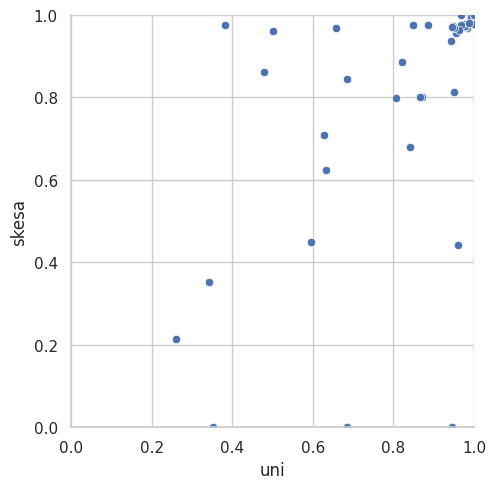

<Figure size 600x600 with 0 Axes>

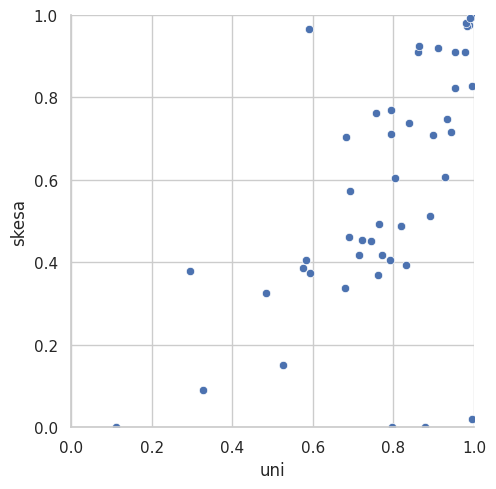

<Figure size 600x600 with 0 Axes>

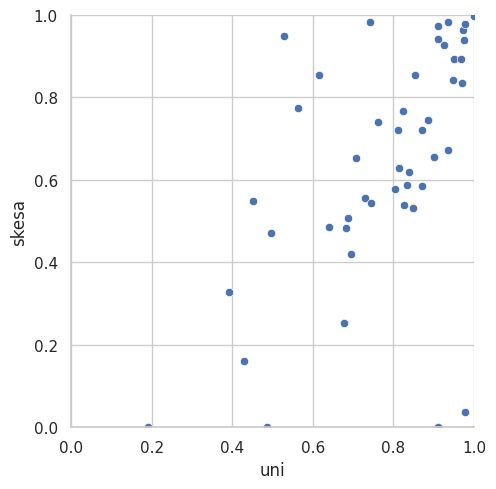

In [53]:
# Labeling Gplas (skesa vs unicycler)
# PRECISION
# SAMPLE, METRIC, UNI, SKESA

df_labeling = pd.read_csv(f"{test_id}.labeling.cut.csv", sep='\t')
# df_binning = pd.read_csv(f"{test_id}.binning.cut.csv", sep='\t')

df_labeling = pd.read_csv(f"{test_id}.binning.cut.csv", sep='\t')

df_gplas_skesa = df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "gplas")]
df_gplas_skesa_precision = df_gplas_skesa[["sample", "prec"]].rename(columns={"prec": "skesa"})

df_gplas_uni = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "gplas")]
df_gplas_uni_precision = df_gplas_uni[["sample", "prec"]].rename(columns={"prec": "uni"})

df_gplas_precision = df_gplas_skesa_precision.merge(df_gplas_uni_precision, on="sample")
df_gplas_precision.head()

plt.figure(figsize=(6, 6))
p = sns.relplot(
    data=df_gplas_precision,
    y="skesa",
    x="uni",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))


df_gplas_skesa = df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "gplas")]
df_gplas_skesa_rec = df_gplas_skesa[["sample", "rec"]].rename(columns={"rec": "skesa"})

df_gplas_uni = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "gplas")]
df_gplas_uni_rec = df_gplas_uni[["sample", "rec"]].rename(columns={"rec": "uni"})

df_gplas_rec = df_gplas_skesa_rec.merge(df_gplas_uni_rec, on="sample")
df_gplas_rec.head()

plt.figure(figsize=(6, 6))
p = sns.relplot(
    data=df_gplas_rec,
    y="skesa",
    x="uni",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))


df_gplas_skesa = df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "gplas")]
df_gplas_skesa_f1 = df_gplas_skesa[["sample", "f1"]].rename(columns={"f1": "skesa"})

df_gplas_uni = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "gplas")]
df_gplas_uni_f1 = df_gplas_uni[["sample", "f1"]].rename(columns={"f1": "uni"})

df_gplas_f1 = df_gplas_skesa_f1.merge(df_gplas_uni_f1, on="sample")
df_gplas_f1.head()

plt.figure(figsize=(6, 6))
p = sns.relplot(
    data=df_gplas_f1,
    y="skesa",
    x="uni",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))



# TABELLA NUMERO SAMPLES MEGLIO PBFu/PBFs/PBFMEDIA/PANGENOMA


<Figure size 600x600 with 0 Axes>

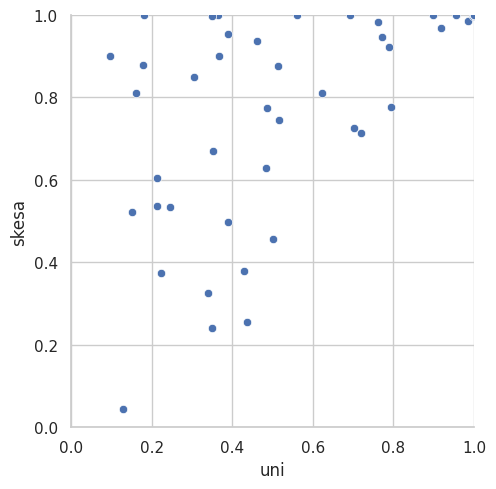

<Figure size 600x600 with 0 Axes>

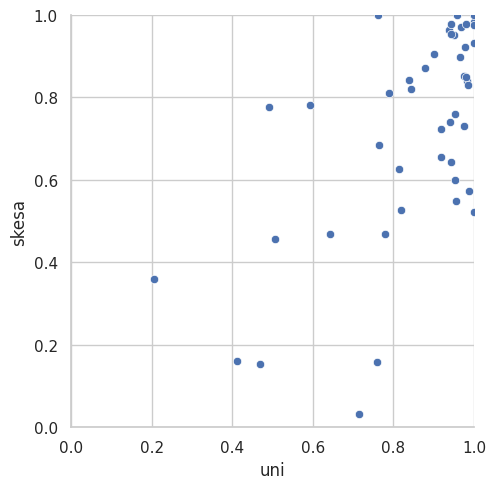

<Figure size 600x600 with 0 Axes>

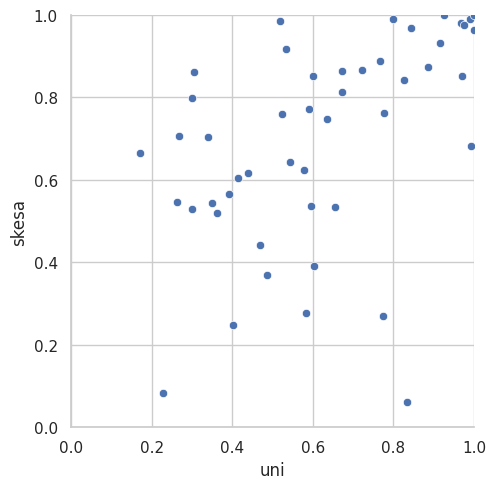

In [54]:
# Labeling Gplas (skesa vs unicycler)
# PRECISION
# SAMPLE, METRIC, UNI, SKESA
df_pbf_skesa = df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "pbf")]
df_pbf_skesa_precision = df_pbf_skesa[["sample", "prec"]].rename(columns={"prec": "skesa"})

df_pbf_uni = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "pbf")]
df_pbf_uni_precision = df_pbf_uni[["sample", "prec"]].rename(columns={"prec": "uni"})

df_pbf_precision = df_pbf_skesa_precision.merge(df_pbf_uni_precision, on="sample")
df_pbf_precision.head()

plt.figure(figsize=(6, 6))
p = sns.relplot(
    data=df_pbf_precision,
    y="skesa",
    x="uni",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))


df_pbf_skesa = df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "pbf")]
df_pbf_skesa_rec = df_pbf_skesa[["sample", "rec"]].rename(columns={"rec": "skesa"})

df_pbf_uni = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "pbf")]
df_pbf_uni_rec = df_pbf_uni[["sample", "rec"]].rename(columns={"rec": "uni"})

df_pbf_rec = df_pbf_skesa_rec.merge(df_pbf_uni_rec, on="sample")
df_pbf_rec.head()

plt.figure(figsize=(6, 6))
p = sns.relplot(
    data=df_pbf_rec,
    y="skesa",
    x="uni",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))


df_pbf_skesa = df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "pbf")]
df_pbf_skesa_f1 = df_pbf_skesa[["sample", "f1"]].rename(columns={"f1": "skesa"})

df_pbf_uni = df_labeling[(df_labeling["tool"] == "1.uni") & (df_labeling["model"] == "pbf")]
df_pbf_uni_f1 = df_pbf_uni[["sample", "f1"]].rename(columns={"f1": "uni"})

df_pbf_f1 = df_pbf_skesa_f1.merge(df_pbf_uni_f1, on="sample")
df_pbf_f1.head()

plt.figure(figsize=(6, 6))
p = sns.relplot(
    data=df_pbf_f1,
    y="skesa",
    x="uni",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))


In [55]:


df_pbf_skesa= df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "pbf")]
df_pbf_skesa = df_pbf_skesa.groupby(["sample"]).mean(numeric_only=True).reset_index()

df_gplas_skesa = df_labeling[(df_labeling["tool"] == "1.ske") & (df_labeling["model"] == "gplas")]
df_gplas_skesa = df_gplas_skesa.groupby(["sample"]).mean(numeric_only=True).reset_index()


df_plot = df_pbf_skesa[["sample", "prec"]].merge(df_gplas_skesa[["sample", "prec"]], on="sample", suffixes=("_pbf", "_gplas"))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_plot, x="prec_pbf", y="prec_gplas", label="LABELING").set(xlim=(0, 1), ylim=(0,1))
# sns.scatterplot(data=df_gplas_unicycler, x="prec", y="rec", label="GPLAS")
# sns.scatterplot(data=df_pangebin, x="prec", y="rec", label="Pangebin")
plt.title("Labeling Precision - Skesa assembly")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_prec_ske.pdf")
plt.close()


df_plot = df_pbf_skesa[["sample", "rec"]].merge(df_gplas_skesa[["sample", "rec"]], on="sample", suffixes=("_pbf", "_gplas"))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_plot, x="rec_pbf", y="rec_gplas", label="RECALL", ).set(xlim=(0, 1), ylim=(0,1))

# sns.scatterplot(data=df_gplas_unicycler, x="prec", y="rec", label="GPLAS")
# sns.scatterplot(data=df_pangebin, x="prec", y="rec", label="Pangebin")
plt.title("Labeling Recall - Skesa assembly")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_rec_ske.pdf")
plt.close()

df_plot = df_pbf_skesa[["sample", "f1"]].merge(df_gplas_skesa[["sample", "f1"]], on="sample", suffixes=("_pbf", "_gplas"))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_plot, x="f1_pbf", y="f1_gplas", label="F1-SCORE", ).set(xlim=(0, 1), ylim=(0,1))

# sns.scatterplot(data=df_gplas_unicycler, x="prec", y="rec", label="GPLAS")
# sns.scatterplot(data=df_pangebin, x="prec", y="rec", label="Pangebin")
plt.title("Labeling F1-Score - Skesa assembly")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_f1_ske.pdf")
plt.close()





In [56]:

df_plot = df_pbf_skesa[["sample", "f1"]].merge(df_gplas_skesa[["sample", "f1"]], on="sample", suffixes=("_pbf", "_gplas"))
# add a new column named metric
df_plot["metric"] = "f1"
df_plot = df_plot.rename(columns={"f1_pbf": "pbf", "f1_gplas": "gplas"})
df_plot = df_plot[["sample", "metric", "pbf", "gplas", ]]
df_plot.head()


df_rec = df_pbf_skesa[["sample", "rec"]].merge(df_gplas_skesa[["sample", "rec"]], on="sample", suffixes=("_pbf", "_gplas"))
df_rec["metric"] = "recall"
df_rec = df_rec.rename(columns={"rec_pbf": "pbf", "rec_gplas": "gplas"})
df_rec = df_rec[["sample", "metric", "pbf", "gplas", ]]
df_rec.head()

df_prec = df_pbf_skesa[["sample", "prec"]].merge(df_gplas_skesa[["sample", "prec"]], on="sample", suffixes=("_pbf", "_gplas"))
df_prec["metric"] = "precision"
df_prec = df_prec.rename(columns={"prec_pbf": "pbf", "prec_gplas": "gplas"})
df_prec = df_prec[["sample", "metric", "pbf", "gplas", ]]
df_prec.head()

df_plot = pd.concat([df_plot, df_rec, df_prec], ignore_index=True)

plt.figure(figsize=(6,6))
p = sns.relplot(
    data=df_plot,
    y="gplas",
    x="pbf",
    # col="metric",
    hue="metric",
    kind="scatter",
).set(xlim=(0, 1), ylim=(0,1))
p.fig.subplots_adjust(top=.95)
plt.title("Labeling - Skesa assembly for 48 samples")
plt.xlabel("Plasbin-Flow")
plt.ylabel("Gplas")
plt.savefig("misc/plot/lab_ske.pdf")
plt.close()


<Figure size 600x600 with 0 Axes>

In [57]:
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
df_binning = pd.read_csv(f"{test_id}.binning.cut.csv", sep='\t')


plt.

In [58]:
df_pbf_unicycler= df_binning[(df_binning["tool"] == "1.uni") & (df_binning["model"] == "pbf")]
df_pbf_unicycler = df_pbf_unicycler.groupby(["sample"]).mean(numeric_only=True).reset_index()

df_gplas_unicycler = df_binning[(df_binning["tool"] == "1.uni") & (df_binning["model"] == "gplas")]
df_gplas_unicycler = df_gplas_unicycler.groupby(["sample"]).mean(numeric_only=True).reset_index()

df_pangebin = df_binning[(df_binning["tool"]=="1.pan") & (df_binning["model"] == "pbf")]
df_pangebin = df_pangebin.groupby(["sample"]).mean(numeric_only=True).reset_index()

df_pangebin.head()



,sample,prec,rec,f1
0,SAMD00056131,0.902718,0.719768,0.800846
1,SAMEA3357010,0.822327,0.990609,0.898652
2,SAMEA3357043,0.711273,0.983864,0.825581
3,SAMEA3357080,0.238909,0.862944,0.374209
4,SAMEA3357223,0.068706,0.950357,0.128141


In [59]:
df_pbf_skesa= df_binning[(df_binning["tool"] == "1.ske") & (df_binning["model"] == "pbf")]
df_pbf_skesa = df_pbf_skesa.groupby(["sample"]).mean(numeric_only=True).reset_index()

df_gplas_skesa = df_binning[(df_binning["tool"] == "1.ske") & (df_binning["model"] == "gplas")]
df_gplas_skesa = df_gplas_skesa.groupby(["sample"]).mean(numeric_only=True).reset_index()

In [60]:
# df_plot definition
# sample, tool, score, score_value
# SAMNXX, pbf, prec, 0.9
# SAMNXX, pbf, rec, 0.8
# SAMNXX, pbf, f1, 0.85
# SAMNXX, gplas, prec, 0.9
# SAMNXX, gplas, rec, 0.8
# SAMNXX, gplas, f1, 0.85
# SAMNXX, pan, prec, 0.9
# SAMNXX, pan, rec, 0.8
# SAMNXX, pan, f1, 0.85
header = ["sample", "tool", "score", "score_value"]
df_plot = pd.DataFrame(columns=header)
df_plot = pd.concat([df_pbf_unicycler[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pbf").assign(score="prec"), df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pbf_unicycler[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="pbf").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pbf_unicycler[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="pbf").assign(score="f1"), 
    df_plot], ignore_index=True)


df_plot = pd.concat([
    df_gplas_unicycler[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="gplas").assign(score="prec"), 
    df_plot], ignore_index=True)

df_plot = pd.concat([
    df_gplas_unicycler[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="gplas").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_gplas_unicycler[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="gplas").assign(score="f1"), 
    df_plot], ignore_index=True) 


df_plot_uni = df_plot
df_plot = pd.concat([
    df_pangebin[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pan").assign(score="prec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="pan").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="pan").assign(score="f1"),
    df_plot], ignore_index=True)


/tmp/ipykernel_2804689/3772474614.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_plot = pd.concat([df_pbf_unicycler[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pbf").assign(score="prec"), df_plot], ignore_index=True)


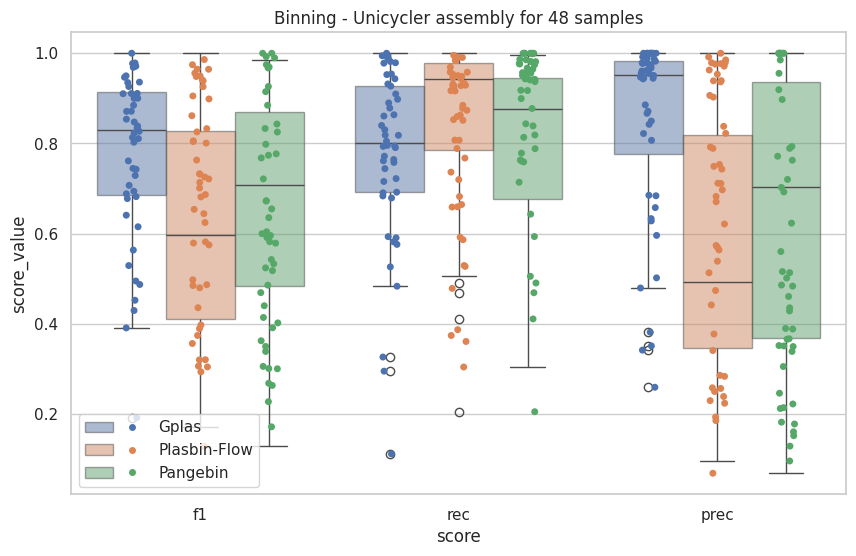

In [61]:
plt.figure(figsize=(10, 6))
p = sns.boxplot(
    data=df_plot,
    x="score",
    y="score_value",
    hue="tool",
    hue_order=["gplas", "pbf", "pan"],
    boxprops=dict(alpha=.5),
)
sns.stripplot(data=df_plot, x="score", y="score_value", hue="tool", hue_order=["gplas", "pan", "pbf"],
    dodge=True, ax=p)

handles, labels = p.get_legend_handles_labels()
p.legend(handles=[(handles[0], handles[3]), (handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Gplas', 'Plasbin-Flow', 'Pangebin'],
          loc='lower left', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})

# p.fig.subplots_adjust(top=.95)
plt.title("Binning - Unicycler assembly for 48 samples")
# plt.xlabel("Plasbin-Flow")
# plt.ylabel("Gplas")
plt.savefig("misc/plot/bin_uni.pdf")
# plt.close()



---
---


In [62]:
# LABELING/BINNING

# SCATTERPLOT 1.uni, gplas vs pbf
# SCATTERPLOT 1.ske, gplas vs pbf
# SCATTERPLOT mean, gplas vs pbf
# BOXPLOT gplas vs pbf vs pangebin


/tmp/ipykernel_2804689/1243607603.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_plot = pd.concat([df_pbf_skesa[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pbf").assign(score="prec"), df_plot], ignore_index=True)


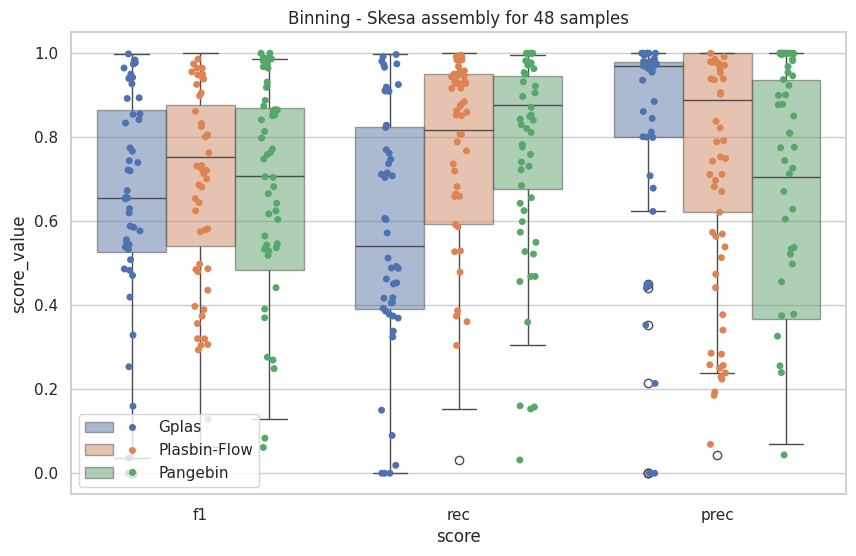

In [71]:
 # df_plot definition
# sample, tool, score, score_value
# SAMNXX, pbf, prec, 0.9
# SAMNXX, pbf, rec, 0.8
# SAMNXX, pbf, f1, 0.85
# SAMNXX, gplas, prec, 0.9
# SAMNXX, gplas, rec, 0.8
# SAMNXX, gplas, f1, 0.85
# SAMNXX, pan, prec, 0.9
# SAMNXX, pan, rec, 0.8
# SAMNXX, pan, f1, 0.85
header = ["sample", "tool", "score", "score_value"]
df_plot = pd.DataFrame(columns=header)
df_plot = pd.concat([df_pbf_skesa[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pbf").assign(score="prec"), df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pbf_skesa[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="pbf").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pbf_skesa[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="pbf").assign(score="f1"), 
    df_plot], ignore_index=True)


df_plot = pd.concat([
    df_gplas_skesa[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="gplas").assign(score="prec"), 
    df_plot], ignore_index=True)

df_plot = pd.concat([
    df_gplas_skesa[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="gplas").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_gplas_skesa[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="gplas").assign(score="f1"), 
    df_plot], ignore_index=True) 

df_plot_ske = df_plot

df_plot = pd.concat([
    df_pangebin[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pan").assign(score="prec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="pan").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="pan").assign(score="f1"),
    df_plot], ignore_index=True)


plt.figure(figsize=(10, 6))
p = sns.boxplot(
    data=df_plot,
    x="score",
    y="score_value",
    hue="tool",
    hue_order=["gplas", "pbf", "pan"],
    boxprops=dict(alpha=.5),

)
sns.stripplot(data=df_plot, x="score", y="score_value", hue="tool", hue_order=["gplas", "pan", "pbf"],
    dodge=True, ax=p)

handles, labels = p.get_legend_handles_labels()
p.legend(handles=[(handles[0], handles[3]), (handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Gplas', 'Plasbin-Flow', 'Pangebin'],
          loc='lower left', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})

# p.fig.subplots_adjust(top=.95)
plt.title("Binning - Skesa assembly for 48 samples")
# plt.xlabel("Plasbin-Flow")
# plt.ylabel("Gplas")
plt.savefig("misc/plot/bin_ske.pdf")
# plt.close()




In [70]:

df_plot_all = pd.concat([df_plot_uni.assign(typ="uni"), df_plot_ske.assign(typ="ske")], ignore_index=True)

df_plot = df_plot_all

df_plot = pd.concat([
    df_pangebin[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pan").assign(score="prec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="pan").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="pan").assign(score="f1"),
    df_plot], ignore_index=True)

df_plot.head()

,sample,score_value,tool,score,typ
0,SAMD00056131,0.800846,pan,f1,NaN
1,SAMEA3357010,0.898652,pan,f1,NaN
2,SAMEA3357043,0.825581,pan,f1,NaN
3,SAMEA3357080,0.374209,pan,f1,NaN
4,SAMEA3357223,0.128141,pan,f1,NaN


In [65]:
df_plot_mean = pd.concat([df_plot_uni, df_plot_ske], ignore_index=True)
df_plot_mean = df_plot_mean.groupby(["sample", "tool", "score"]).mean(numeric_only=True).reset_index()
df_plot_mean.head()

df_plot = df_plot_mean

df_plot = pd.concat([
    df_pangebin[["sample", "prec"]].rename(columns={"prec": "score_value"}).assign(tool="pan").assign(score="prec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "rec"]].rename(columns={"rec": "score_value"}).assign(tool="pan").assign(score="rec"), 
    df_plot], ignore_index=True)
df_plot = pd.concat([
    df_pangebin[["sample", "f1"]].rename(columns={"f1": "score_value"}).assign(tool="pan").assign(score="f1"),
    df_plot], ignore_index=True)

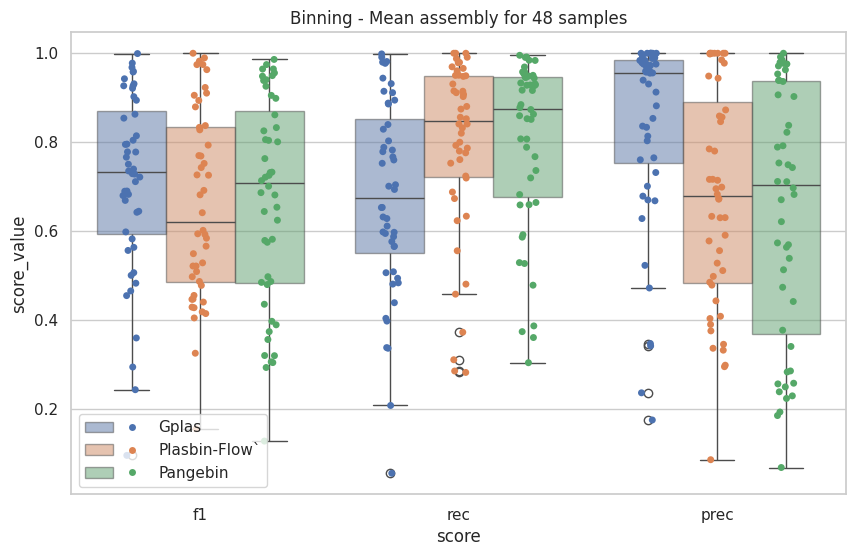

In [66]:
plt.figure(figsize=(10, 6))
p = sns.boxplot(
    data=df_plot,
    x="score",
    y="score_value",
    hue="tool",
    hue_order=["gplas", "pbf", "pan"],
    boxprops=dict(alpha=.5),

)
sns.stripplot(data=df_plot, x="score", y="score_value", hue="tool", hue_order=["gplas", "pbf", "pan"],
    dodge=True, ax=p)

handles, labels = p.get_legend_handles_labels()
p.legend(handles=[(handles[0], handles[3]), (handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Gplas', 'Plasbin-Flow`', 'Pangebin'],
          loc='lower left', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})

# p.fig.subplots_adjust(top=.95)
plt.title("Binning - Mean assembly for 48 samples")
# plt.xlabel("Plasbin-Flow")
# plt.ylabel("Gplas")
plt.savefig("misc/plot/bin_mean.pdf")
# plt.close()


In [67]:
# GPLAS uni sa
# PBF uni ske#
# PBF mean
# Pangebin